# Implementing Ridge Regression from Scratch 

We need to add the lambda*m^2 term to the loss function and as usual, we need to minimise the loss function. We will use the same process as we used in the simple linear regression earlier, only that a new term has been added to the loss function which is going to chnage the value of m .

In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [17]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

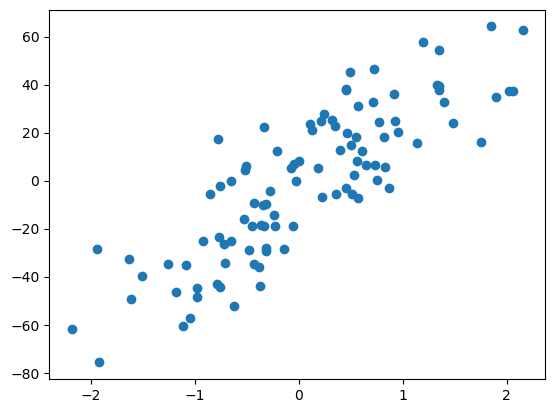

In [18]:
plt.scatter(X, y)

In [20]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y, y_pred)
rmse = np.sqrt(r2_score(y, y_pred))

print(r2)
print(rmse)
print(lr.coef_)
print(lr.intercept_)

0.7035182396294912
0.8387599415980065
[27.82809103]
-2.29474455867698


In [21]:
from sklearn.linear_model import Ridge

In [26]:
rr = Ridge(alpha = 10)
rr.fit(X, y)
print(rr.coef_)
print(rr.intercept_)
r2 = r2_score(y, rr.predict(X))
rmse = np.sqrt(r2_score(y, rr.predict(X)))

print(r2)
print(rmse)

[24.9546267]
-2.126913003523574
0.6960172225909294
0.8342764665210983


Notice that the value of m has decreased while the value of intercept has increased.

In [27]:
rr1 = Ridge(alpha=100)
rr1.fit(X, y)
print(rr1.coef_)
print(rr1.intercept_)

r2 = r2_score(y, rr1.predict(X))
rmse = np.sqrt(r2_score(y, rr1.predict(X)))

print(r2)
print(rmse)

[12.93442104]
-1.4248441496033313
0.5020011026155695
0.7085203614685815


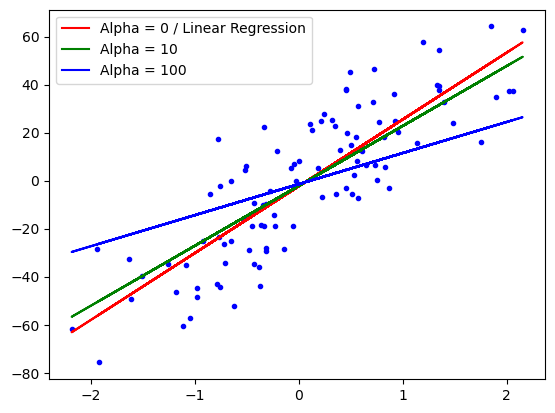

In [25]:
plt.plot(X, y, 'b.')
plt.plot(X, lr.predict(X), color = 'red', label = 'Alpha = 0 / Linear Regression')
plt.plot(X, rr.predict(X), color = 'green', label = 'Alpha = 10')
plt.plot(X, rr1.predict(X), color = 'blue', label = 'Alpha = 100')
plt.legend()
plt.show()

See how the high alpha value causes underfitting.

# Manual Implementation of Ridge Regression

In [35]:
class manualRidge:

    def __init__(self, alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0 # numerator, will do summation using a loop
        den = 0 # denominator

        x_mean = X_train.mean()
        y_mean = y_train.mean()

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_mean)*(X_train[i] - x_mean)
            den = den + (X_train[i] - x_mean)*(X_train[i] - x_mean) 

        den += self.alpha # this is the change compared to the normal linear Regression

        self.m = num/den
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m, self.b)
    
    def predict(X_test):
        pass

In [36]:
reg = manualRidge(alpha=10)

In [37]:
reg.fit(X, y)

[24.9546267] [-2.126913]


The results are same as that from the inbuilt Ridge class and alpha = 10 we calculated above

## Lets work on nD Data ( n-input columns )

We will have to work on n+1 unknowns, n corresponding to the n input x and 1 is the intercept.

We have worked on the concept in the previous topics, we just need to take care of the new alpha/lambda part here.

In [39]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [40]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
from sklearn.linear_model import ridge_regression

## Using Library

In [41]:
reg = Ridge(alpha=0.1, solver='cholesky')
reg.fit(X_train, y_train)

Ridge(alpha=0.1, solver='cholesky')

In [43]:
y_pred = reg.predict(X_test)
print(r2_score(y_test, y_pred))

0.46931288533098037


In [44]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


## Lets do the manual Implementation

In [45]:
class manualRidge:
    def __init__(self, alpha = 0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis = 1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

The changes we did above:

1) Added a '1' column as the 0th column of the X_Train matrix, this is the X matrix we will need for all the calculations
2) Then we made an identity matrix whose shape will be same as that of X_train, we need this for multiplication with lambdas, the coefficients.
3) Result is the matrix with 1st element as the intercept and rest as the coefficients.

In [46]:
reg = manualRidge()
reg.fit(X_train, y_train)
y_pred1 = reg.predict(X_test)
print(r2_score(y_test, y_pred1))
print(reg.coef_)
print(reg.intercept_)

0.46921361559931885
[  44.04252774 -241.72019592  452.99153345  332.06044266  -76.32617866
  -68.54884462 -165.01664054  149.93980143  431.59483654   58.54419942]
150.8476272002316


See the results are similar but not exactly same if we take a close look. Because the library uses the I[0][0] as 0 for thier working.